# Relationship Stability: Outcome Construction and Descriptive Analysis

## #1 Set-up and load shared data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
DATA_PATH = Path("../data/processed/hcmst_analysis_base.csv")
TABLE_DIR = Path("../output/tables")
FIGURE_DIR = Path("../output/figures")

# Load shared cleaned dataset
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (4002, 25)


## #2 Verify relationship stability 

In [30]:
relationship_vars = [
    "w2_relationship_end",
    "w3_relationship_end_combo",
    "w2_relationship_duration",
    "w3_relationship_duration_yrs"
]

# Check whether all required variables are in the shared dataset
for var in relationship_vars:
    print(var, "->", var in df.columns)

w2_relationship_end -> False
w3_relationship_end_combo -> False
w2_relationship_duration -> False
w3_relationship_duration_yrs -> False


## #3 Inspect available relationship variables
Identify the relationship-related variables retained in the shared dataset and verify their exact variable names before constructing the relationship stability outcome.

In [4]:
# Display all variables currently available in the shared dataset
print("Variables in shared dataset:\n")

for col in df.columns:
    print(col)

Variables in shared dataset:

caseid_new
weight1
weight2
weight3
ppincimp
ppeduc
q10
q23
income_ordinal
income_tertile
respondent_edu_group
partner_edu_group
respondent_edu_score
partner_edu_score
education_comparison
w2_q5
w2_q9
w3_q5
w3_q9
how_long_relationship
ppethm
pp2_ppethm
pp3_ppethm
q6a
q6b


## #4 Inspect Wave 2 and Wave 3's 
Examine the values and distributions of the retained Wave 2 and Wave 3 variables before determining how relationship stability and duration should be operationalised.

In [5]:
# Inspect possible Wave 2 and Wave 3 relationship variables
relationship_vars = [
    "w2_q5",
    "w2_q9",
    "w3_q5",
    "w3_q9",
    "how_long_relationship"
]

for var in relationship_vars:
    print("\n" + "=" * 50)
    print(var)
    print("=" * 50)
    print(df[var].value_counts(dropna=False).sort_index())


w2_q5
w2_q5
no      225
yes     650
NaN    3127
Name: count, dtype: int64

w2_q9
w2_q9
[partner] passed away, is deceased       7
other (please describe)                 35
we broke up                            182
NaN                                   3778
Name: count, dtype: int64

w3_q5
w3_q5
no       96
yes     472
NaN    3434
Name: count, dtype: int64

w3_q9
w3_q9
Other (please describe)                16
Refused                                 1
We broke up                            71
[xNameP] passed away, is deceased       8
NaN                                  3906
Name: count, dtype: int64

how_long_relationship
how_long_relationship
0.00        1
0.05       29
0.15       53
0.45       54
0.75       83
         ... 
69.00       2
70.00       2
71.00       1
76.00       1
NaN      1019
Name: count, Length: 76, dtype: int64


## #5 Examine Relationship Variables
Inspect the unique values and missingness of the candidate relationship variables to determine their coding and suitability for constructing the relationship stability outcome.

In [6]:
# Compact inspection of candidate relationship variables
for var in ["w2_q5", "w2_q9", "w3_q5", "w3_q9", "how_long_relationship"]:
    print("\n" + "=" * 60)
    print(var)
    print("=" * 60)

    print("Non-missing N:", df[var].notna().sum())
    print("Missing N:", df[var].isna().sum())
    print("Number of unique non-missing values:", df[var].nunique())

    print("\nFirst 20 unique values:")
    print(df[var].dropna().unique()[:20])


w2_q5
Non-missing N: 875
Missing N: 3127
Number of unique non-missing values: 2

First 20 unique values:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

w2_q9
Non-missing N: 224
Missing N: 3778
Number of unique non-missing values: 3

First 20 unique values:
<StringArray>
['we broke up', 'other (please describe)',
 '[partner] passed away, is deceased']
Length: 3, dtype: str

w3_q5
Non-missing N: 568
Missing N: 3434
Number of unique non-missing values: 2

First 20 unique values:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

w3_q9
Non-missing N: 96
Missing N: 3906
Number of unique non-missing values: 4

First 20 unique values:
<StringArray>
[                      'We broke up',           'Other (please describe)',
 '[xNameP] passed away, is deceased',                           'Refused']
Length: 4, dtype: str

how_long_relationship
Non-missing N: 2983
Missing N: 1019
Number of unique non-missing values: 75

First 20 unique values:
[ 7.    8.   12.   30.    4.   27.   15.   14.   

## #6 Identify Candidate Duration Variables

Examine the relationship-duration variables retained from the original HCMST dataset to determine which measure is appropriate for the relationship stability analysis.

In [7]:
# Check which duration variables are available in the shared dataset
duration_vars = [
    "duration",
    "w2_duration",
    "w3_duration",
    "how_long_relationship"
]

for var in duration_vars:
    print(var, "->", var in df.columns)

duration -> False
w2_duration -> False
w3_duration -> False
how_long_relationship -> True


## #7 Cross-Check Relationship Status and End Variables

Cross-tabulate the Wave 2 and Wave 3 yes/no variables with the corresponding relationship-end reason variables to examine their survey logic before constructing the stability outcome.

In [8]:
# Cross-check Wave 2 survey logic
print("WAVE 2: w2_q5 × w2_q9")
print(
    pd.crosstab(
        df["w2_q5"],
        df["w2_q9"],
        dropna=False,
        margins=True
    )
)

print("\nWAVE 3: w3_q5 × w3_q9")
print(
    pd.crosstab(
        df["w3_q5"],
        df["w3_q9"],
        dropna=False,
        margins=True
    )
)

WAVE 2: w2_q5 × w2_q9
w2_q9  [partner] passed away, is deceased  other (please describe)  \
w2_q5                                                                
no                                      7                       35   
yes                                     0                        0   
NaN                                     0                        0   
All                                     7                       35   

w2_q9  we broke up   NaN   All  
w2_q5                           
no             182     1   225  
yes              0   650   650  
NaN              0  3127  3127  
All            182  3778  4002  

WAVE 3: w3_q5 × w3_q9
w3_q9  Other (please describe)  Refused  We broke up  \
w3_q5                                                  
no                          16        1           71   
yes                          0        0            0   
NaN                          0        0            0   
All                         16        1           71   


## #8 Examine Wave-to-Wave Relationship Stability

Compare Wave 2 and Wave 3 relationship-status responses to examine longitudinal consistency, follow-up participation, and missingness before constructing the final binary stability outcome.

In [9]:
# Cross-tabulate Wave 2 and Wave 3 relationship status
wave_status = pd.crosstab(
    df["w2_q5"],
    df["w3_q5"],
    dropna=False,
    margins=True
)

print("Wave 2 × Wave 3 relationship status:")
print(wave_status)

Wave 2 × Wave 3 relationship status:
w3_q5  no  yes   NaN   All
w2_q5                     
no      0    0   225   225
yes    73  441   136   650
NaN    23   31  3073  3127
All    96  472  3434  4002


## #9 Investigate Wave 3 Cases Missing Wave 2

Examine respondents with missing Wave 2 relationship status but observed Wave 3 status to determine whether Wave 3 information can validly contribute to the final stability measure.

In [10]:
# Examine respondents with no Wave 2 status but an observed Wave 3 status
w3_only = df[
    df["w2_q5"].isna() &
    df["w3_q5"].notna()
][[
    "caseid_new",
    "w2_q5",
    "w2_q9",
    "w3_q5",
    "w3_q9"
]]

print("Number of respondents with missing W2 but observed W3:", len(w3_only))
print("\nWave 3 status distribution:")
print(w3_only["w3_q5"].value_counts(dropna=False))

print("\nWave 3 end reason by Wave 3 status:")
print(
    pd.crosstab(
        w3_only["w3_q5"],
        w3_only["w3_q9"],
        dropna=False,
        margins=True
    )
)

Number of respondents with missing W2 but observed W3: 54

Wave 3 status distribution:
w3_q5
yes    31
no     23
Name: count, dtype: int64

Wave 3 end reason by Wave 3 status:
w3_q9  Other (please describe)  We broke up  \
w3_q5                                         
no                           4           18   
yes                          0            0   
All                          4           18   

w3_q9  [xNameP] passed away, is deceased  NaN  All  
w3_q5                                               
no                                     1    0   23  
yes                                    0   31   31  
All                                    1   31   54  


## #10 Construct Final Relationship Stability Variable

Construct a binary measure of relationship stability using the latest available follow-up information. Relationships confirmed to have ended by Wave 2 or Wave 3 are coded as dissolved (0), while relationships confirmed to remain intact at Wave 3 are coded as stable (1). Cases without sufficient follow-up information to determine the relationship outcome are retained as missing rather than treated as relationship dissolution.

In [11]:
# Initialise stability variable as missing
df["relationship_stable"] = pd.NA

# Stable through Wave 3:
# relationship is explicitly confirmed as intact at Wave 3
df.loc[df["w3_q5"] == "yes", "relationship_stable"] = 1

# Dissolved by Wave 3:
# relationship is explicitly reported as ended at Wave 3
df.loc[df["w3_q5"] == "no", "relationship_stable"] = 0

# Dissolved by Wave 2:
# these respondents are structurally not asked about the relationship again at Wave 3
df.loc[df["w2_q5"] == "no", "relationship_stable"] = 0

# Use nullable integer type so 0/1 and missing values are preserved
df["relationship_stable"] = df["relationship_stable"].astype("Int64")

## #11 Validate Relationship Stability Outcome

Check the distribution of the newly constructed binary stability variable and verify that its coding is consistent with the original Wave 2 and Wave 3 relationship-status responses.

In [12]:
# Frequency distribution
print("Relationship stability counts:")
print(df["relationship_stable"].value_counts(dropna=False))

print("\nRelationship stability percentages (valid cases only):")
print(
    df["relationship_stable"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTotal N:", len(df))
print("Valid stability outcomes:", df["relationship_stable"].notna().sum())
print("Unknown / missing outcomes:", df["relationship_stable"].isna().sum())

Relationship stability counts:
relationship_stable
<NA>    3209
1        472
0        321
Name: count, dtype: Int64

Relationship stability percentages (valid cases only):
relationship_stable
1    59.52
0    40.48
Name: proportion, dtype: Float64

Total N: 4002
Valid stability outcomes: 793
Unknown / missing outcomes: 3209


## #12 Relationship Stability Descriptive Table

Summarise the number and percentage of classifiable relationships that remained stable or dissolved across the follow-up period.

In [13]:
# Create descriptive table for valid stability outcomes
stability_table = (
    df["relationship_stable"]
    .dropna()
    .value_counts()
    .rename_axis("relationship_stable")
    .reset_index(name="N")
)

# Add readable labels
stability_table["Status"] = stability_table["relationship_stable"].map({
    1: "Stable",
    0: "Dissolved"
})

# Calculate percentages among valid cases
stability_table["Percent"] = (
    stability_table["N"] / stability_table["N"].sum() * 100
).round(2)

# Arrange columns
stability_table = stability_table[
    ["Status", "N", "Percent"]
]

print(stability_table)

      Status    N  Percent
0     Stable  472    59.52
1  Dissolved  321    40.48


In [14]:
stability_table.to_csv(
    TABLE_DIR / "relationship_stability_summary.csv",
    index=False
)

print("Saved relationship stability summary table.")

Saved relationship stability summary table.


## #13 Assess Follow-Up Availability and Missingness

Examine the availability of relationship-status information across Waves 2 and 3. Because some missing values may arise from questionnaire skip patterns rather than survey attrition alone, observed and missing relationship-status responses are reported separately.

In [15]:
# Count observed relationship-status responses at each wave
wave_followup = pd.DataFrame({
    "Wave": ["Wave 2", "Wave 3"],
    "Observed_N": [
        df["w2_q5"].notna().sum(),
        df["w3_q5"].notna().sum()
    ],
    "Missing_N": [
        df["w2_q5"].isna().sum(),
        df["w3_q5"].isna().sum()
    ]
})

wave_followup["Observed_Percent"] = (
    wave_followup["Observed_N"] / len(df) * 100
).round(2)

wave_followup["Missing_Percent"] = (
    wave_followup["Missing_N"] / len(df) * 100
).round(2)

print(wave_followup)

     Wave  Observed_N  Missing_N  Observed_Percent  Missing_Percent
0  Wave 2         875       3127             21.86            78.14
1  Wave 3         568       3434             14.19            85.81


## #14 Inspect Wave-Specific Survey Weights

Examine the Wave 1, Wave 2, and Wave 3 survey weights to determine whether they can be used to identify participation across follow-up waves and distinguish panel attrition from questionnaire skip-pattern missingness.

In [16]:
# Inspect wave-specific survey weights
for var in ["weight1", "weight2", "weight3"]:
    print("\n" + "=" * 50)
    print(var)
    print("=" * 50)

    print("Non-missing N:", df[var].notna().sum())
    print("Missing N:", df[var].isna().sum())
    print("Zero values:", (df[var] == 0).sum())
    
    print("\nSummary:")
    print(df[var].describe())


weight1
Non-missing N: 4002
Missing N: 0
Zero values: 0

Summary:
count      4002.000000
mean      56424.619690
std       49248.983612
min         522.000000
25%       20025.250000
50%       49370.500000
75%       74526.250000
max      264379.000000
Name: weight1, dtype: float64

weight2
Non-missing N: 3009
Missing N: 993
Zero values: 0

Summary:
count      3009.000000
mean      56502.959787
std       49138.848705
min         522.000000
25%       22455.000000
50%       49016.000000
75%       73527.000000
max      264379.000000
Name: weight2, dtype: float64

weight3
Non-missing N: 3009
Missing N: 993
Zero values: 0

Summary:
count      3009.000000
mean      56502.959787
std       49138.848705
min         522.000000
25%       22455.000000
50%       49016.000000
75%       73527.000000
max      264379.000000
Name: weight3, dtype: float64


## #15 Summarise Wave Weight Availability

Summarise the availability of wave-specific survey weights as a potential indicator of follow-up coverage. These counts are kept separate from relationship-status response counts because weight availability does not necessarily correspond exactly to completion of the relationship-status questions.

In [17]:
# Summarise availability of wave-specific weights
weight_availability = pd.DataFrame({
    "Wave": ["Wave 1", "Wave 2", "Wave 3"],
    "Weight_Available_N": [
        df["weight1"].notna().sum(),
        df["weight2"].notna().sum(),
        df["weight3"].notna().sum()
    ],
    "Weight_Missing_N": [
        df["weight1"].isna().sum(),
        df["weight2"].isna().sum(),
        df["weight3"].isna().sum()
    ]
})

weight_availability["Weight_Available_Percent"] = (
    weight_availability["Weight_Available_N"] / len(df) * 100
).round(2)

print(weight_availability)

     Wave  Weight_Available_N  Weight_Missing_N  Weight_Available_Percent
0  Wave 1                4002                 0                    100.00
1  Wave 2                3009               993                     75.19
2  Wave 3                3009               993                     75.19


## #16 Validate Relationship Duration

Examine the distribution and range of the available relationship-duration measure before using it as a secondary outcome. Check for missing values, impossible negative values, and unusually large values that may require further investigation.

In [18]:
# Validate relationship duration variable
duration = df["how_long_relationship"]

print("Relationship duration summary:")
print(duration.describe())

print("\nMissing N:", duration.isna().sum())
print("Valid N:", duration.notna().sum())

print("\nPotential data-quality checks:")
print("Negative durations:", (duration < 0).sum())
print("Zero-year durations:", (duration == 0).sum())
print("Durations > 60 years:", (duration > 60).sum())

print("\nLargest observed durations:")
print(duration.sort_values(ascending=False).head(20).to_string(index=False))

Relationship duration summary:
count    2983.000000
mean       17.708331
std        15.658864
min         0.000000
25%         5.000000
50%        13.000000
75%        26.000000
max        76.000000
Name: how_long_relationship, dtype: float64

Missing N: 1019
Valid N: 2983

Potential data-quality checks:
Negative durations: 0
Zero-year durations: 1
Durations > 60 years: 38

Largest observed durations:
76.0
71.0
70.0
70.0
69.0
69.0
68.0
66.0
66.0
66.0
66.0
66.0
65.0
65.0
65.0
65.0
64.0
64.0
64.0
63.0


## #17 Create Relationship Duration Measure

Use the available `how_long_relationship` measure as the secondary relationship-duration variable. No observations are removed based on the range check because no negative durations are present and the observed maximum remains substantively plausible.

In [20]:
# Create final relationship-duration variable
df["relationship_duration_years"] = df["how_long_relationship"].copy()

print("Final relationship duration variable:")
print(df["relationship_duration_years"].describe())

print("\nMissing N:",
      df["relationship_duration_years"].isna().sum())

Final relationship duration variable:
count    2983.000000
mean       17.708331
std        15.658864
min         0.000000
25%         5.000000
50%        13.000000
75%        26.000000
max        76.000000
Name: relationship_duration_years, dtype: float64

Missing N: 1019


## #18 Plot Relationship Duration Distribution

Visualise the distribution of observed relationship duration to describe the secondary relationship-stability measure and identify the overall shape of the distribution.

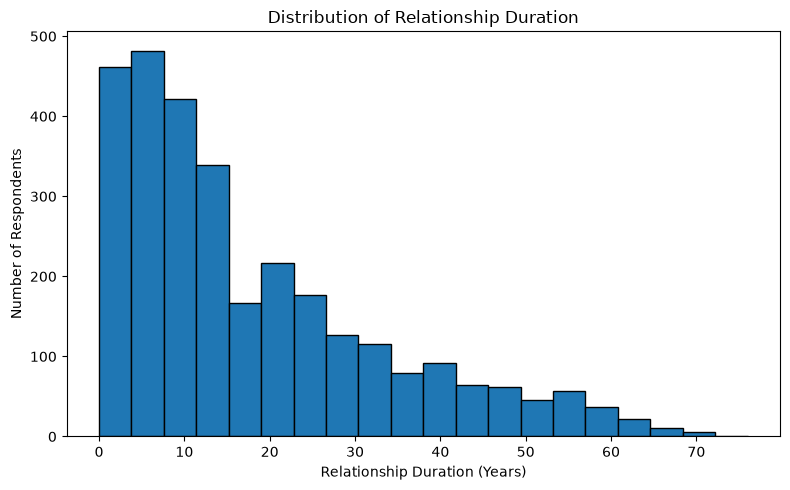

In [21]:
# Plot relationship duration distribution
plt.figure(figsize=(8, 5))

plt.hist(
    df["relationship_duration_years"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.xlabel("Relationship Duration (Years)")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Relationship Duration")

plt.tight_layout()

# Save figure
plt.savefig(
    FIGURE_DIR / "relationship_duration_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## #19 Compare Relationship Duration by Stability Outcome

Compare relationship duration between relationships classified as stable and dissolved. This provides a descriptive secondary comparison of relationship duration across the two stability outcomes.

In [22]:
# Compare relationship duration by stability outcome

duration_by_stability = (
    df.dropna(subset=["relationship_stable", "relationship_duration_years"])
      .groupby("relationship_stable")["relationship_duration_years"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

# Add readable labels
duration_by_stability.index = duration_by_stability.index.map({
    1: "Stable",
    0: "Dissolved"
})

print("Relationship duration by stability:")
print(duration_by_stability)

Relationship duration by stability:
                     count  mean  median   std
relationship_stable                           
Dissolved              318  5.27     1.5  8.34
Stable                 469  9.63     7.0  9.05


## #20 Plot Mean Relationship Duration by Stability

Visualise the mean relationship duration among relationships classified as stable and dissolved. This comparison is descriptive and does not imply that relationship duration causes subsequent stability.

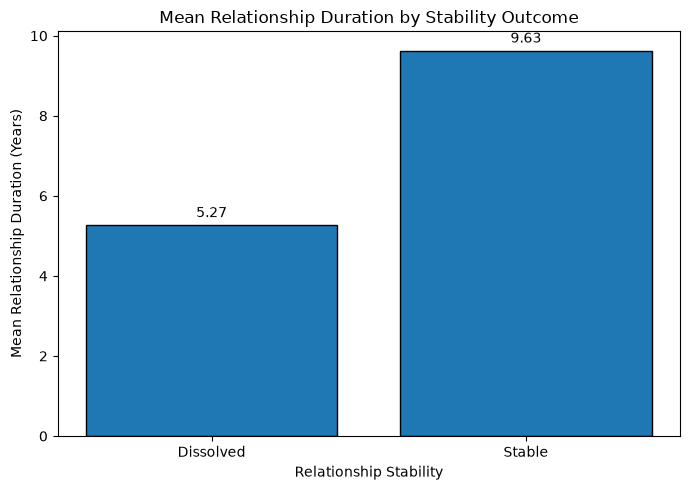

In [23]:
# Plot mean relationship duration by stability outcome

mean_duration = (
    df.dropna(subset=["relationship_stable", "relationship_duration_years"])
      .groupby("relationship_stable")["relationship_duration_years"]
      .mean()
      .rename(index={0: "Dissolved", 1: "Stable"})
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    mean_duration.index,
    mean_duration.values,
    edgecolor="black"
)

plt.ylabel("Mean Relationship Duration (Years)")
plt.xlabel("Relationship Stability")
plt.title("Mean Relationship Duration by Stability Outcome")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "relationship_duration_by_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## #21 Save Relationship Stability Output Tables

Save the descriptive relationship-stability and duration summaries for use in the group analysis and final report.

In [31]:
# Save relationship-stability descriptive tables

stability_table.to_csv(
    TABLE_DIR / "relationship_stability_summary.csv",
    index=False
)

duration_by_stability.to_csv(
    TABLE_DIR / "relationship_duration_by_stability.csv"
)

weight_availability.to_csv(
    TABLE_DIR / "wave_weight_availability.csv",
    index=False
)

print("Saved relationship stability output tables:")
print("- relationship_stability_summary.csv")
print("- relationship_duration_by_stability.csv")
print("- wave_weight_availability.csv")

Saved relationship stability output tables:
- relationship_stability_summary.csv
- relationship_duration_by_stability.csv
- wave_weight_availability.csv


## #22 Verify Shared Dataset Before Updating

Perform final integrity checks before adding the relationship-stability variables to the shared processed dataset. Confirm the dataset dimensions, respondent identifier, duplicate IDs, and presence of the newly constructed relationship variables before saving.

In [32]:
# Final integrity checks before updating shared dataset

print("Dataset shape:", df.shape)

print("\nRespondent ID check:")
print("caseid_new present:", "caseid_new" in df.columns)
print("Unique IDs:", df["caseid_new"].nunique())
print("Missing IDs:", df["caseid_new"].isna().sum())
print("Duplicate IDs:", df["caseid_new"].duplicated().sum())

print("\nRelationship-stability variables:")
print("relationship_stable present:",
      "relationship_stable" in df.columns)
print("relationship_duration_years present:",
      "relationship_duration_years" in df.columns)

print("\nRelationship-stability variable availability:")
print(
    df[[
        "relationship_stable",
        "relationship_duration_years"
    ]].notna().sum()
)

print("\nCurrent number of columns:", len(df.columns))

Dataset shape: (4002, 27)

Respondent ID check:
caseid_new present: True
Unique IDs: 4002
Missing IDs: 0
Duplicate IDs: 0

Relationship-stability variables:
relationship_stable present: True
relationship_duration_years present: True

Relationship-stability variable availability:
relationship_stable             793
relationship_duration_years    2983
dtype: int64

Current number of columns: 27


## #23 Update Shared Analysis Dataset

In [27]:
from pathlib import Path

# Locate the existing shared dataset WITHOUT changing anything
possible_paths = [
    Path("../data/processed/hcmst_analysis_base.csv"),
    Path("data/processed/hcmst_analysis_base.csv"),
]

for path in possible_paths:
    print(path, "-> exists:", path.exists())

../data/processed/hcmst_analysis_base.csv -> exists: True
data/processed/hcmst_analysis_base.csv -> exists: False


In [33]:
# Save updated relationship-stability dataset as a NEW file
# Original hcmst_analysis_base.csv is NOT modified

RELATIONSHIP_PATH = Path("../data/processed/hcmst_analysis_base_relationship_stability.csv")

df.to_csv(
    RELATIONSHIP_PATH,
    index=False
)

print("Relationship-stability dataset saved separately to:")
print(RELATIONSHIP_PATH)

print("\nOriginal shared dataset still exists:")
print(Path("../data/processed/hcmst_analysis_base.csv").exists())

Relationship-stability dataset saved separately to:
../data/processed/hcmst_analysis_base_relationship_stability.csv

Original shared dataset still exists:
True


In [34]:
# Reload relationship-stability file and verify it

df_check = pd.read_csv(RELATIONSHIP_PATH)

print("Shape:", df_check.shape)

print("\nID checks:")
print("Unique IDs:", df_check["caseid_new"].nunique())
print("Missing IDs:", df_check["caseid_new"].isna().sum())
print("Duplicate IDs:", df_check["caseid_new"].duplicated().sum())

print("\nRelationship-stability variables:")
print(
    df_check[
        ["relationship_stable", "relationship_duration_years"]
    ].notna().sum()
)

print("\nStability distribution:")
print(df_check["relationship_stable"].value_counts(dropna=False))

Shape: (4002, 27)

ID checks:
Unique IDs: 4002
Missing IDs: 0
Duplicate IDs: 0

Relationship-stability variables:
relationship_stable             793
relationship_duration_years    2983
dtype: int64

Stability distribution:
relationship_stable
NaN    3209
1.0     472
0.0     321
Name: count, dtype: int64
